In [78]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    # print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    # print("no cupy")

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import FDTDIResponseGenerator
from Triangle_BBH.Utils import Likelihood, Fstatistics
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114517)
# xp.random.seed(114514)

In [79]:
class WaveformGenerator():
    def __init__(self, mode='full'):
        """ 
            vectorized wrapper of the PhenomHM waveform 
            using the Fourier transformation convension of S. Marsat
            h_lm(f) = A_lm(f) exp[i Phi_lm(f)]
            t_lm(f) = d Phi_lm(f) / df / 2PI
            with Phi_lm(f) being -Psi_lm(f) in the paper
            
            mode = 'full': HM waveform
            mode = 'primary': D waveform
        """
        self.waveform = WF.IMRPhenomHM(mode=mode)
    
    def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, freqs=None):
        """  
            parameters = {
                "name" : numpy array of shape (Nevents),
                ...
            }
            the parameters include:
            "chirp_mass" [MSUN], "mass_ratio" [1], "spin_1z" [1], "spin_2z" [1], 
            "coalescence_time" [DAY] (SSB), "coalescence_phase" [rad],
            "luminosity_distance" [MPC], "inclination" [rad], 
            "longitude" [rad], "latitude" [rad], "psi" [rad]
            11 parameters in total
            *** NOTE ***************
            1. the coalescence frequency is set to the internal cut frequency of WF4Py - 1e-4 Hz (for numerical reason)
            2. coalescence time has to be converted to tc at the SSB origin.
            3. coalescence phase parameter is ignored and set to 0
            ************************
            freqs should be None or numpy array of shape (Nevents, Nfreqs)
            
            Calculate the mode-independent frequency grids of shape (Nevents, Nfreqs), 
            and mode-dependent (Nevents, Nfreqs) arrays of GW amplitudes, phases and t-f relationships, 
            stored in dictionaries with the keys being mode numbers.
            e.g. amps_out = {
                (l, m) : (Nevents, Nfreqs) array,
                ...
            }
        """
        Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        
        # conversion of parameters
        parameters_in = {}
        parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
        parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
        parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
        parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
        parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
        parameters_in['coalescence_time'] = np.atleast_1d(parameters['coalescence_time'])
        
        # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
        if type(freqs) == np.ndarray:
            if freqs.shape[0] == Nevents:
                fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
            else: 
                fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
        else:
            fminarr = np.full(Nevents, fmin)
            fmaxarr = np.full(Nevents, fmax)
            fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs)) # (Nfreqs, Nevents)
            
        self.fcutarr = self.waveform.fcut(**parameters_in) # (Nevents) TEST 
        FSTEP = 1e-6 # TEST 
        self.fcutarr = self.fcutarr - 1e-4 # TEST 
        fgrids_cut = np.array([
            self.fcutarr - FSTEP, 
            self.fcutarr
        ]) # (2, Nevents) TEST 

        fgrids = np.concatenate((fgrids, fgrids_cut), axis=0) # (Nfreqs + 2, Nevents)
        
        # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs+2, Nevents) array (will be transposed)
        amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
        phases = self.waveform.Phi(fgrids, **parameters_in) # dict
        # phases_cut = self.waveform.Phi(fgrids_cut, **parameters_in) # dict, each mode of shape (2, Nevents) TEST 
        
        # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)] and shapes to (Nevents, Nfreqs)
        amps_out = {}
        phas_out = {}
        # phas_out_cut = {} # TEST 
        for k, v in amplitudes.items():
            amps_out[(int(k[0]), int(k[1]))] = (v.T)[:, :-2] # (Nevents, Nfreqs)
            phas_out[(int(k[0]), int(k[1]))] = phases[k].T # (Nevents, Nfreqs+2)
            # phas_out_cut[(int(k[0]), int(k[1]))] = phases_cut[k].T # (Nevents, 2) # TEST 
        fgrids = fgrids.T # (Nevents, Nfreqs+2)
        
        # dphase_22_cut = (phas_out_cut[(2,2)][:, 1] - phas_out_cut[(2,2)][:, 0]) / FSTEP # phase derivative (Nevents) TEST 
        dphase_22_cut = (phas_out[(2,2)][:, -1] - phas_out[(2,2)][:, -2]) / FSTEP # phase derivative (Nevents) TEST 
        phase_mode_correction1 = (-dphase_22_cut + TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] * (fgrids - self.fcutarr[:, np.newaxis]) # (Nevents, Nfreqs+2) TEST
        # phase_22_cut = np.array([np.interp(x=self.fcutarr[ievent], xp=fgrids[ievent], fp=phas_out[(2,2)][ievent]) for ievent in range(Nevents)]) # (Nevents), TEST 
        phase_22_cut = phas_out[(2,2)][:, -1] # (Nevents)
        for k, v in phas_out.items(): 
            phase_mode_correction2 = -0.5 * k[1] * phase_22_cut # -m/2 * phi_cut_22 (Nevents) TEST 
            phas_out[k] = (v + phase_mode_correction1 + phase_mode_correction2[:, np.newaxis])[:, :-2] # (Nevents, Nfreqs)
        
        fgrids = fgrids[:, :-2] # (Nevents, Nfreqs)
        # calculate time grids by t-f relationship 
        tfs_out = {}
        dfgrids = np.gradient(fgrids, axis=1) # (Nevents, Nfreqs) TEST 
        for k, v in phas_out.items(): 
            dphase = np.gradient(v, axis=1) # (Nevents, Nfreqs) TEST 
            tfs_out[k] = dphase / dfgrids / TWOPI # (Nevents, Nfreqs) TEST 
 
        return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [80]:
# class WaveformGenerator():
#     def __init__(self, mode='full'):
#         """ 
#             vectorized wrapper of the PhenomHM waveform 
#             using the Fourier transformation convension of S. Marsat
#             h_lm(f) = A_lm(f) exp[i Phi_lm(f)]
#             t_lm(f) = d Phi_lm(f) / df / 2PI
#             with Phi_lm(f) being -Psi_lm(f) in the paper
            
#             mode = 'full': HM waveform
#             mode = 'primary': D waveform
#         """
#         self.waveform = WF.IMRPhenomHM(mode=mode)
    
#     def __call__(self, parameters, Nfreqs=1024, fmin=1e-5, fmax=1e-1, freqs=None):
#         """  
#             parameters = {
#                 "name" : numpy array of shape (Nevents),
#                 ...
#             }
#             the parameters include:
#             "chirp_mass" [MSUN], "mass_ratio" [1], "spin_1z" [1], "spin_2z" [1], 
#             "coalescence_time" [DAY] (SSB), "coalescence_phase" [rad],
#             "luminosity_distance" [MPC], "inclination" [rad], 
#             "longitude" [rad], "latitude" [rad], "psi" [rad]
#             11 parameters in total
#             *** NOTE that coalescence time has to be converted to tc at the SSB origin.
#             *** NOTE that coalescence phase parameter is ignored and set to 0
#             freqs should be None or numpy array of shape (Nevents, Nfreqs)
            
#             Calculate the mode-independent frequency grids of shape (Nevents, Nfreqs), 
#             and mode-dependent (Nevents, Nfreqs) arrays of GW amplitudes, phases and t-f relationships, 
#             stored in dictionaries with the keys being mode numbers.
#             e.g. amps_out = {
#                 (l, m) : (Nevents, Nfreqs) array,
#                 ...
#             }
#         """
#         Nevents = np.atleast_1d(parameters["chirp_mass"]).shape[0]
        
#         # conversion of parameters
#         parameters_in = {}
#         parameters_in["Mc"] = np.atleast_1d(parameters["chirp_mass"])
#         parameters_in["eta"] = np.atleast_1d(eta_q(parameters["mass_ratio"]))
#         parameters_in["chi1z"] = np.atleast_1d(parameters["spin_1z"])
#         parameters_in["chi2z"] = np.atleast_1d(parameters["spin_2z"])
#         parameters_in["dL"] = np.atleast_1d(parameters["luminosity_distance"] / 1e3) 
#         parameters_in['coalescence_time'] = np.atleast_1d(parameters['coalescence_time'])
        
#         # calculate frequency grids of shape (Nfreqs, Nevents) (will be transposed later), independent of modes
#         # NOTE: for later convenience fgrid must be the same for all events
#         if type(freqs) == np.ndarray:
#             if freqs.shape[0] == Nevents:
#                 fgrids = np.transpose(freqs) # (Nfreqs, Nevents)
#             else: 
#                 fgrids = np.transpose(np.tile(freqs, (Nevents, 1))) # (Nevents, Nfreqs) -> (Nfreqs, Nevents)
#         else:
#             # fcutarr = self.waveform.fcut(**parameters_in)
#             # fmaxarr = np.full(fcutarr.shape, min(np.min(fcutarr), fmax))
#             # fminarr = np.full(fcutarr.shape, fmin)
            
#             fminarr = np.full(Nevents, fmin)
#             fmaxarr = np.full(Nevents, fmax)            
            
#             fgrids = np.geomspace(fminarr, fmaxarr, num=int(Nfreqs))
            
        
#         # calculate amplitudes, phases by modes, each mode is originally a (Nfreqs, Nevents) array (will be transposed)
#         amplitudes = self.waveform.Ampl(fgrids, **parameters_in) # dict
#         phases = self.waveform.Phi(fgrids, **parameters_in) # dict
#         # adjust keys to [(2,2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)] and shapes to (Nevents, Nfreqs)
#         amps_out = {}
#         phas_out = {}
#         for k, v in amplitudes.items():
#             amps_out[(int(k[0]), int(k[1]))] = v.T 
#             phas_out[(int(k[0]), int(k[1]))] = phases[k].T 
#         fgrids = fgrids.T 
            
#         # set t_ref = 0, phi_ref = 0 
#         # This step may result in slightly different phases for different resolutions. Therefore it is recommanded to keep consistency in terms of frequency resolution,  
#         #  or otherwise, optimization of tc, phic would be required to get coincident results. 
#         ind_ref = np.argmax(fgrids ** 2 * amps_out[(2, 2)], axis=1)
#         f_ref = fgrids[np.arange(Nevents), ind_ref] # (Nevents)
#         f_ref_1 = fgrids[np.arange(Nevents), ind_ref - 1]
#         phase_22_ref = phas_out[(2, 2)][np.arange(Nevents), ind_ref] # (Nevents)
#         phase_22_ref_1 = phas_out[(2, 2)][np.arange(Nevents), ind_ref - 1]
#         dphase_22_ref = (phase_22_ref - phase_22_ref_1) / (f_ref - f_ref_1) # (Nevents)
#         phase_correct1 = (fgrids - f_ref[:, np.newaxis]) * (-dphase_22_ref + TWOPI * parameters_in['coalescence_time'] * DAY)[:, np.newaxis] # correct t_ref = tc
#         for k, v in phas_out.items():
#             phase_correct2 = -k[1] * 0.5 * phase_22_ref # correct phi_ref
#             phas_out[k] = v + phase_correct1 + phase_correct2[:, np.newaxis]
        
#         # calculate time grids by t-f relationship 
#         tfs_out = {}
#         dfgrids = np.gradient(fgrids, axis=1)
#         for k, v in phas_out.items():
#             dphase = np.gradient(v, axis=1)
#             tfs_out[k] = dphase / dfgrids / TWOPI 

#         return fgrids, amps_out, phas_out, tfs_out # each item of shape (Nevents, Nfreqs)

In [81]:
t_start = 200. * DAY # start time in s
Tobs = 30. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 10. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
# for i in range(1, 50): 
#     mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
#     mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((129575,), (129601,))

In [82]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    dt=DAY, 
    ) 

# initialize  waveform generator 
WFG = WaveformGenerator(
    # mode="primary", 
    mode="full", 
)

# initialize response generator 
FDTDI = FDTDIResponseGenerator(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

# response settings 
response_kwargs_interp = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1e-1, # used to calculate freq grid
    Nfreqs=1024, # used to calculate freq grid
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

response_kwargs_direct = dict(
    # modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method=None,
)

In [83]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.5 * Tobs) / DAY, (t_end - 0.1 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

# generate source parameter and clean signal 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }
mbhb_parameters

{'chirp_mass': 972287.5907612599,
 'mass_ratio': 0.9533723853486523,
 'spin_1z': -0.7927534695383422,
 'spin_2z': 0.7539705677212488,
 'coalescence_time': 222.50926411177574,
 'coalescence_phase': 0.9287872182324762,
 'luminosity_distance': 26606.888520143497,
 'inclination': 1.4776010552835497,
 'longitude': 3.2721714083974724,
 'latitude': 0.03765624370319295,
 'psi': 3.0793452655721536}

In [84]:
for _ in tqdm(range(1)):
    wf_channels_interp = FDTDI.Response(
        mbhb_parameters, 
        data_frequencies, 
        **response_kwargs_interp,
        )

for _ in tqdm(range(1)):
    wf_channels_direct = FDTDI.Response(
        mbhb_parameters, 
        data_frequencies, 
        **response_kwargs_direct, 
    )

wf_channels_interp.shape, wf_channels_direct.shape 

100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


((3, 129575), (3, 129575))

(5e-05, 0.1)

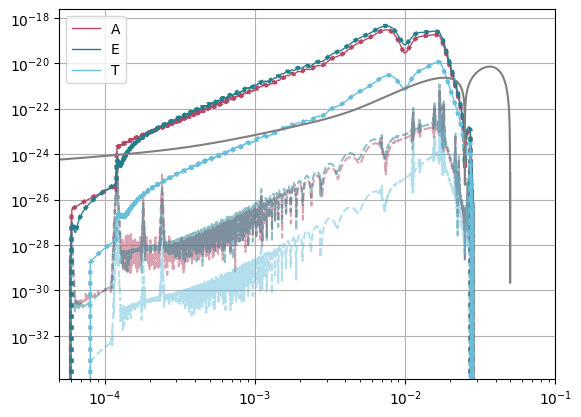

In [85]:
ch_names = ["A", "E", "T"]
ch_colors = [RED, GREEN1, BLUE]
psdfunc = TDIPSDs()
for i in range(3):
    plt.loglog(data_frequencies, np.abs(wf_channels_interp[i]) * 2. * data_frequencies, color=ch_colors[i], label=ch_names[i], linestyle="-", linewidth=1)
    plt.loglog(data_frequencies, np.abs(wf_channels_direct[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle=":", linewidth=3)
    plt.loglog(data_frequencies, np.abs(wf_channels_interp[i] - wf_channels_direct[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle="--", alpha=0.5)
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_X2(data_frequencies) * data_frequencies), color="grey")
plt.legend()
plt.grid()
# plt.ylim(1e-25,)
plt.xlim(5e-5, 0.1)

In [86]:
f_int, amp_int, pha_int, tf_int = WFG(
    parameters=mbhb_parameters, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
)

f_dir, amp_dir, pha_dir, tf_dir = WFG(
    parameters=mbhb_parameters, 
    freqs=data_frequencies, 
)

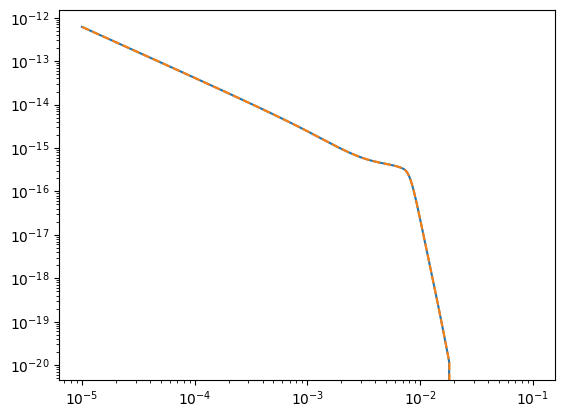

In [87]:
plt.loglog(f_int[0], amp_int[(2,2)][0])
plt.loglog(f_dir[0], amp_dir[(2,2)][0], linestyle="--")

(-0.3141592653589793, 0.3141592653589793)

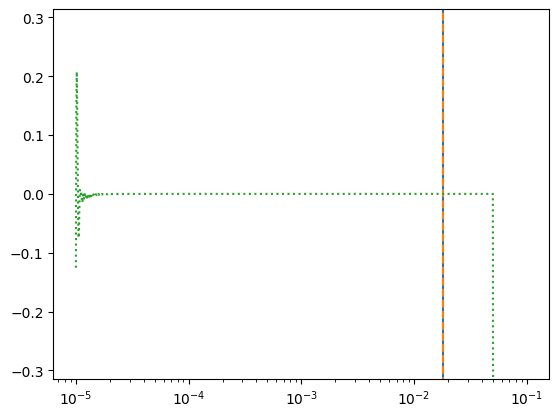

In [88]:
interp_func = CubicSpline(f_dir[0], pha_dir[(2,2)][0])
plt.semilogx(f_int[0], pha_int[(2,2)][0])
plt.semilogx(f_int[0], interp_func(f_int[0]), linestyle="--")
plt.semilogx(f_int[0], interp_func(f_int[0]) - pha_int[(2,2)][0], linestyle=":")
plt.ylim(-PI / 10., PI / 10.)

(-10.0, 10.0)

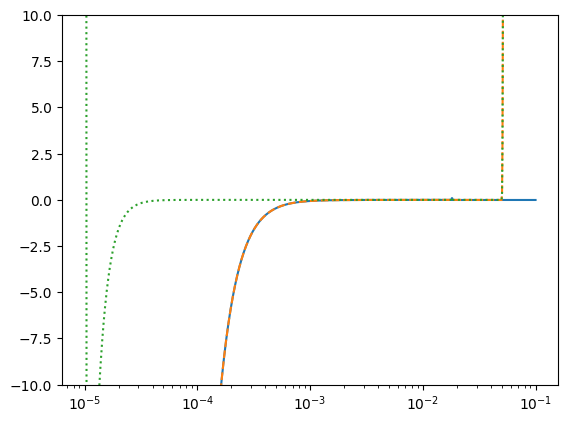

In [89]:
interp_func = CubicSpline(f_dir[0], tf_dir[(2,2)][0])
plt.semilogx(f_int[0], tf_int[(2,2)][0] / DAY - mbhb_parameters["coalescence_time"])
plt.semilogx(f_int[0], interp_func(f_int[0]) / DAY - mbhb_parameters["coalescence_time"], linestyle="--")
plt.semilogx(f_int[0], (interp_func(f_int[0]) - tf_int[(2,2)][0]) / DAY, linestyle=":")
plt.ylim(-10, 10)